# 1. Data Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q2_customers.csv')

# Preview data
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Why Scaling is Important

- K-Means clustering is based on distance (Euclidean distance).
- Features with larger values (e.g., annual_spend) can dominate the clustering process.
- Scaling ensures all features contribute equally.
- This leads to more accurate and unbiased clustering results.


# 2. Choosing K — Elbow Method

In [5]:
df = pd.read_csv('q2_customers.csv')

In [6]:
df.columns

Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased'],
      dtype='object')

In [7]:
from sklearn.preprocessing import StandardScaler

# Step 1: Create X (features only)
X = df.copy() # use your correct target column name

# Step 2: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

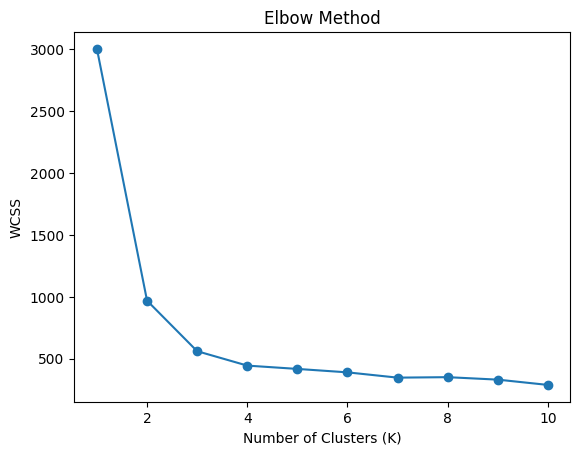

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

## Optimal Number of Clusters

- The elbow point is observed at K = 4.
- After this point, the decrease in WCSS becomes gradual.
- Therefore, K = 4 is chosen as the optimal number of clusters.


# 3. K-Means Clustering

In [9]:
# Apply KMeans with chosen K
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# View dataset
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [10]:
# Cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.157501,1.246698,-1.118685,1.171838,1.965682,1.176784
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.107231,1.224585,-1.094820,1.333700,0.295887,1.169244


## Cluster Interpretation

- Cluster 0: Customers with low spending and fewer visits.
- Cluster 1: High-value customers with high spending and frequent visits.
- Cluster 2: Moderate customers with average spending and behavior.
- Cluster 3: Customers with irreguler visits but moderate spending.

# 4. Dimensionality Reduction with PCA

In [11]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [12]:
# Feature loadings
loadings = pd.DataFrame(
pca.components_,
columns=df.columns[:-1],
index=['PC1', 'PC2']
)
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## PCA Interpretation

- PC1 captures overall customer value and engagement pattern.
Customers with higher PC1 scores tend to have higher annual spending, larger basket sizes, and longer gaps between visits, while lower PC1 values represent frequent visitors with lower spending.

- PC2 primarily captures recency behavior.
It is strongly influenced by days since last visit, indicating whether a customer has visited recently or not.

- Together, PC1 and PC2 explain around 89% of the total variance, meaning most of the dataset information is retained in just two dimensions.

# 5. Cluster Visualisation

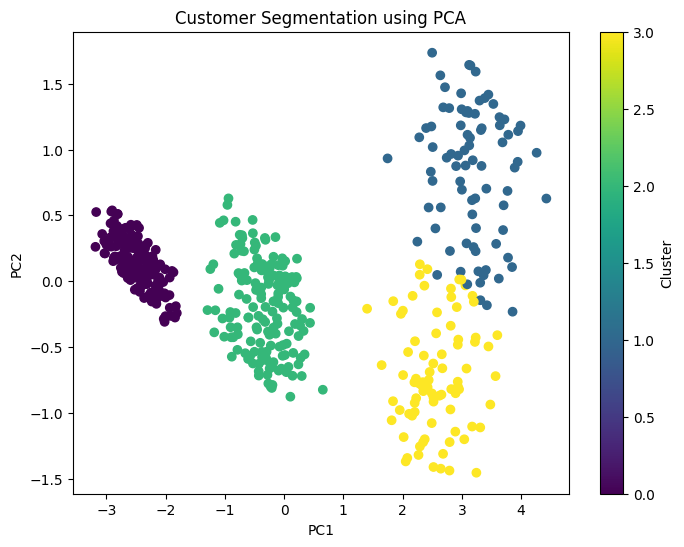

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation using PCA')
plt.colorbar(label='Cluster')
plt.show()



## Conclusion

- Customers were successfully segmented using K-Means clustering.
- The optimal number of clusters was identified using the Elbow Method.
- PCA helped reduce dimensionality and visualize clusters effectively.
- The clusters represent different customer groups based on spending and behavior patterns.
